# NDBC 44013 – Cumulative Wave Power and Dimensionless Settling Velocity

**Station:** NDBC 44013 – Boston, MA (~42.346°N, 70.651°W, ~62 m depth)  
**Period:** 2024-10-01 to 2025-03-30  
**Survey dates:** 2024-10-23, 2025-01-23, 2025-03-06

### Wave power (deep-water energy flux per unit crest width)
$$P = \frac{\rho g^2}{64\pi}\, H_s^2\, T_e \quad \text{(W/m)}, \qquad T_e = T_p / 1.05$$
where $\rho = 1025$ kg/m³, $g = 9.81$ m/s².

### Dimensionless settling velocity
$$\Omega = \frac{H_s}{w_s T_p}$$
where $w_s$ is the sediment fall velocity. $\Omega < 1$ indicates reflective,
$\Omega > 6$ dissipative conditions; intermediate beaches oscillate around $\Omega \approx 3$.  
Reference: Wright & Short (1984), *Marine Geology*, 56, 93–118. https://doi.org/10.1016/0025-3227(84)90008-2

### Inflection points
Upward inflections in the cumulative curves (increases in the *rate* of wave energy or $\Omega$ input)
are identified as local maxima of the second derivative of the cumulative series,
above a threshold. These mark transitions from calm to more energetic conditions.

In [1]:
# csherwood@usgs.gov, 2026-06-26, generated with Claude Sonnet 4.6

import numpy as np
import pandas as pd
import requests
import io
import gzip
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Config ────────────────────────────────────────────────────────────────────
STATION      = '44013'
T_START      = '2024-10-01'
T_END        = '2025-03-30'
SURVEY_DATES = pd.to_datetime(['2024-10-23', '2025-01-23', '2025-03-06'])
XLIM_DAYS    = 14      # days to show on each side of survey date
WS           = 0.0619  # sediment fall velocity (m/s); ws = 6.19 cm/s
CACHE_DIR    = './ndbc'
os.makedirs(CACHE_DIR, exist_ok=True)

# Physical constants
rho   = 1025.0
g     = 9.81
COEFF = rho * g**2 / (64 * np.pi)   # W·s/m³

# Plot style
SHADE_COLOR  = '0.75'   # same shading for all survey dates
SURVEY_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']

In [2]:
# ── Download / cache NDBC stdmet data ────────────────────────────────────────
def fetch_ndbc_year(station, year, cache_dir):
    url_hist   = (f'https://www.ndbc.noaa.gov/data/historical/stdmet/'
                  f'{station}h{year}.txt.gz')
    url_recent = (f'https://www.ndbc.noaa.gov/data/stdmet/'
                  f'{station}/{station}{year}.txt.gz')
    cache_path = os.path.join(cache_dir, f'{station}_{year}.pkl')
    if os.path.exists(cache_path):
        print(f'  {year}: loaded from cache')
        return pd.read_pickle(cache_path)
    for url in [url_hist, url_recent]:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            print(f'  {year}: downloaded from {url}')
            break
    else:
        print(f'  {year}: not found')
        return None
    with gzip.open(io.BytesIO(r.content), 'rt') as f:
        raw = f.read()
    lines  = raw.splitlines()
    header = [h.lstrip('#') for h in lines[0].lstrip('#').split()]
    skip   = 2 if lines[1].lstrip().startswith('#') else 1
    df = pd.read_csv(io.StringIO('\n'.join(lines[skip:])),
                     sep=r'\s+', header=None, names=header,
                     na_values=['99','999','9999','99.0','999.0','9999.0'])
    # Rename time columns by position: YYYY MM DD hh [mi]
    cols = list(df.columns)
    for i, name in enumerate(['YYYY','MM','DD','hh','mi'][:min(5,len(cols))]):
        cols[i] = name
    df.columns = cols
    print(f'  {year} columns: {list(df.columns[:8])}')
    dt_dict = {'year':df['YYYY'],'month':df['MM'],'day':df['DD'],'hour':df['hh']}
    if 'mi' in df.columns:
        dt_dict['minute'] = df['mi']
    df['dt'] = pd.to_datetime(dt_dict)
    df = df.set_index('dt').sort_index()
    df.to_pickle(cache_path)
    return df

frames = []
for yr in [2024, 2025]:
    df_yr = fetch_ndbc_year(STATION, yr, CACHE_DIR)
    if df_yr is not None:
        frames.append(df_yr)
raw_all = pd.concat(frames).sort_index()
print(f'Full record: {raw_all.index[0]} → {raw_all.index[-1]}, {len(raw_all)} rows')

  2024: loaded from cache
  2025: loaded from cache
Full record: 2024-01-01 00:00:00 → 2025-12-31 23:50:00, 105212 rows


In [3]:
# ── Extract Hs, Tp; compute P and Omega ──────────────────────────────────────
waves = raw_all.loc[T_START:T_END, ['WVHT','DPD']].copy()
waves.columns = ['Hs','Tp']
waves = waves.resample('1h').mean()   # hourly, handles duplicates

waves['Te']    = waves['Tp'] / 1.05
waves['P_kWm'] = COEFF * waves['Hs']**2 * waves['Te'] / 1e3   # kW/m
waves['Omega'] = waves['Hs'] / (WS * waves['Tp'])              # dimensionless

print(waves[['Hs','Tp','P_kWm','Omega']].describe().round(2))

            Hs       Tp    P_kWm    Omega
count  4329.00  4293.00  4293.00  4293.00
mean      0.99     6.40     4.00     2.93
std       0.51     2.97     5.39     1.46
min       0.20     2.06     0.06     0.36
25%       0.60     3.85     0.90     1.62
50%       0.89     5.41     1.97     3.01
75%       1.25     8.71     4.92     4.01
max       3.45    17.39    42.77     7.25


In [4]:
# ── Build cumulative forward/backward series around each survey date ──────────
# Cumulative energy flux: sum(P [kW/m] * dt [h]) = kWh/m
# Cumulative Omega: sum(Omega * dt [h])
# Forward:  starts at 0 at survey date, grows rightward
# Backward: starts at 0 at survey date, grows leftward
#           (achieved by reversing the segment, cumsumming, then re-reversing)

DT_H = 1.0   # hours per sample (hourly series)

cum = {}   # cum[key]['fwd'/'bwd'] = DataFrame with P_kWh and Omega_h

for sd in SURVEY_DATES:
    key  = sd.strftime('%Y-%m-%d')
    xlim_lo = sd - pd.Timedelta(days=XLIM_DAYS)
    xlim_hi = sd + pd.Timedelta(days=XLIM_DAYS)

    # Use positional anchor to avoid timestamp-alignment issues
    i0 = waves.index.searchsorted(sd)
    i0 = min(i0, len(waves) - 1)

    # Forward: rows from i0 to end of window
    fwd_seg = waves.loc[waves.index[i0]:xlim_hi, ['P_kWm','Omega']].dropna()
    fwd_cum = fwd_seg.cumsum() * DT_H
    fwd_cum.columns = ['P_kWh','Omega_h']

    # Backward: rows from start of window to i0, reversed, cumsummed, re-reversed
    bwd_seg = waves.loc[xlim_lo:waves.index[i0], ['P_kWm','Omega']].dropna()
    bwd_rev = bwd_seg.iloc[::-1]          # reverse: t0 is now first row
    bwd_cum = (bwd_rev.cumsum() * DT_H).iloc[::-1]  # cumsum then re-reverse
    bwd_cum.columns = ['P_kWh','Omega_h']

    cum[key] = {'fwd': fwd_cum, 'bwd': bwd_cum}
    print(f'{key}  fwd pts: {len(fwd_cum):4d}  bwd pts: {len(bwd_cum):4d}')
    print(f'  fwd P range: 0 → {fwd_cum["P_kWh"].iloc[-1]:.1f} kWh/m')
    print(f'  bwd P range: 0 → {bwd_cum["P_kWh"].iloc[0]:.1f} kWh/m  (at left edge)')

2024-10-23  fwd pts:  336  bwd pts:  337
  fwd P range: 0 → 697.0 kWh/m
  bwd P range: 0 → 1177.6 kWh/m  (at left edge)
2025-01-23  fwd pts:  330  bwd pts:  337
  fwd P range: 0 → 838.3 kWh/m
  bwd P range: 0 → 1103.0 kWh/m  (at left edge)
2025-03-06  fwd pts:  323  bwd pts:  335
  fwd P range: 0 → 1340.9 kWh/m
  bwd P range: 0 → 550.9 kWh/m  (at left edge)


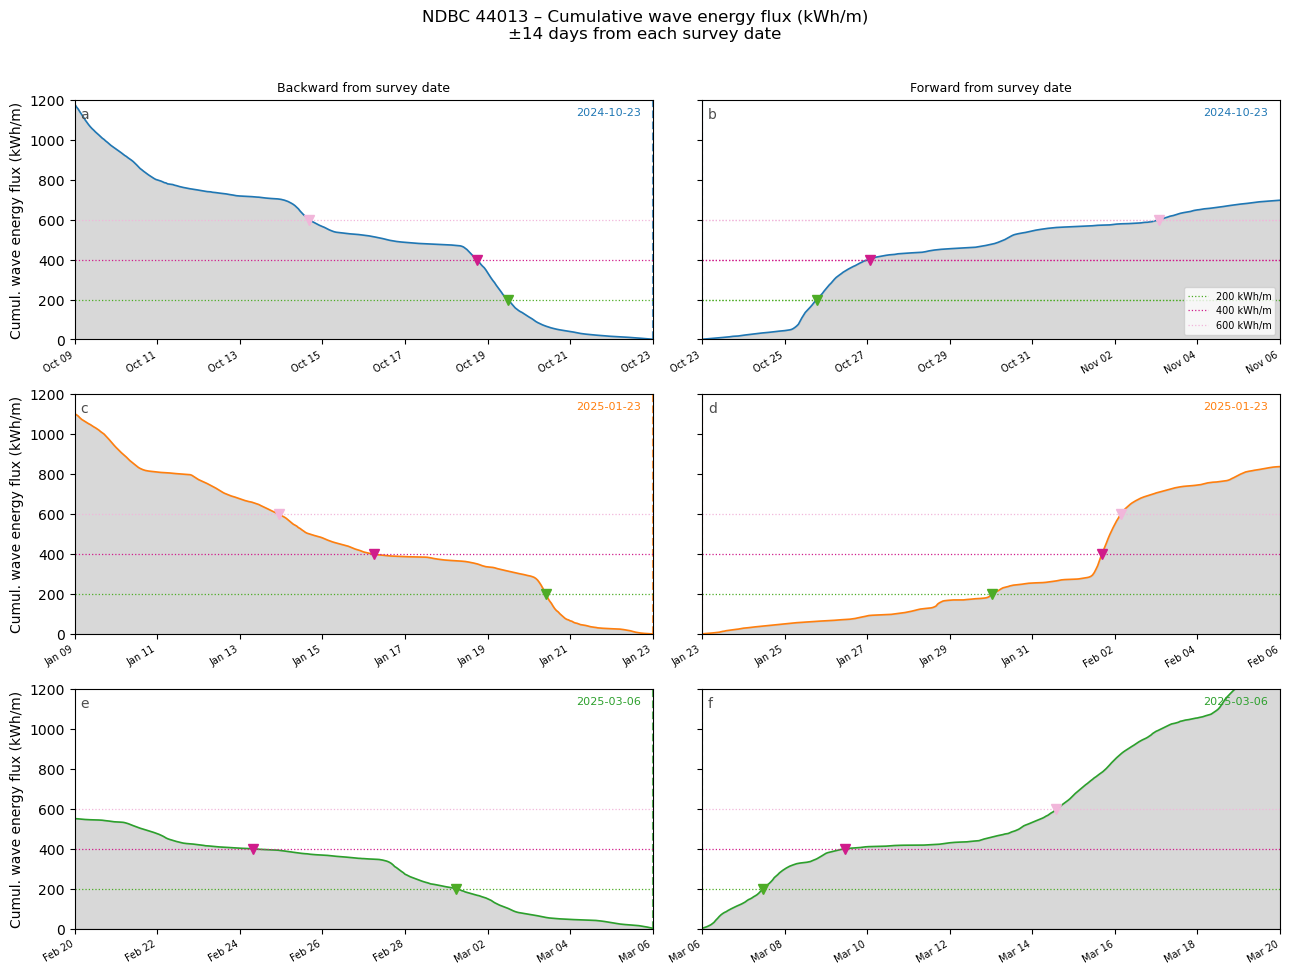

In [5]:
# ── Figure 1 – Cumulative wave power, fixed y-axis with threshold lines ───────
YMAX          = 1200          # fixed y-axis max for both figures
THRESHOLDS    = [200, 400, 600]
THRESH_COLORS = ['#4dac26', '#d01c8b', '#f1b6da']

n_surveys = len(SURVEY_DATES)
fig, axes = plt.subplots(n_surveys, 2, figsize=(13, 3.2 * n_surveys), sharey=True)

panel_letters = [chr(ord('a') + i) for i in range(2 * n_surveys)]
panel_idx = 0

for row, (sd, sc) in enumerate(zip(SURVEY_DATES, SURVEY_COLORS)):
    key = sd.strftime('%Y-%m-%d')

    for col, (direction, title) in enumerate([
            ('bwd', 'Backward from survey date'),
            ('fwd', 'Forward from survey date')]):

        s  = cum[key][direction]['P_kWh']
        ax = axes[row, col]

        ax.fill_between(s.index, s.values, color=SHADE_COLOR, alpha=0.6)
        ax.plot(s.index, s.values, color=sc, lw=1.2)
        ax.axvline(sd, color=sc, lw=1.5, ls='--', alpha=0.8)

        for thresh, tc in zip(THRESHOLDS, THRESH_COLORS):
            ax.axhline(thresh, color=tc, lw=0.9, ls=':', zorder=2)
            above = s.values >= thresh
            diff  = np.diff(above.astype(int))
            sign  = 1 if direction == 'fwd' else -1
            cross = np.where(diff == sign)[0]
            for i in cross:
                frac    = (thresh - s.values[i]) / (s.values[i+1] - s.values[i])
                t_cross = s.index[i] + frac * (s.index[i+1] - s.index[i])
                ax.plot(t_cross, thresh, marker='v', color=tc, ms=7, zorder=5)

        ax.set_xlim(s.index[0], s.index[-1])
        ax.set_ylim(0, YMAX)
        if col == 0:
            ax.set_ylabel('Cumul. wave energy flux (kWh/m)')
        if row == 0:
            ax.set_title(title, fontsize=9)
        ax.text(0.01, 0.97, panel_letters[panel_idx],
                transform=ax.transAxes, va='top', ha='left', fontsize=10, color='0.3')
        panel_idx += 1
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
        ax.text(0.98, 0.97, key, transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color=sc)

# Threshold legend
for thresh, tc in zip(THRESHOLDS, THRESH_COLORS):
    axes[0,1].axhline(thresh, color=tc, lw=0.9, ls=':', label=f'{thresh} kWh/m')
axes[0,1].legend(fontsize=7, loc='lower right')

fig.suptitle(f'NDBC {STATION} – Cumulative wave energy flux (kWh/m)\n'
             f'±{XLIM_DAYS} days from each survey date', y=1.01)
plt.tight_layout()
plt.savefig(f'NDBC_{STATION}_cumpower.png', dpi=150, bbox_inches='tight')
plt.show()

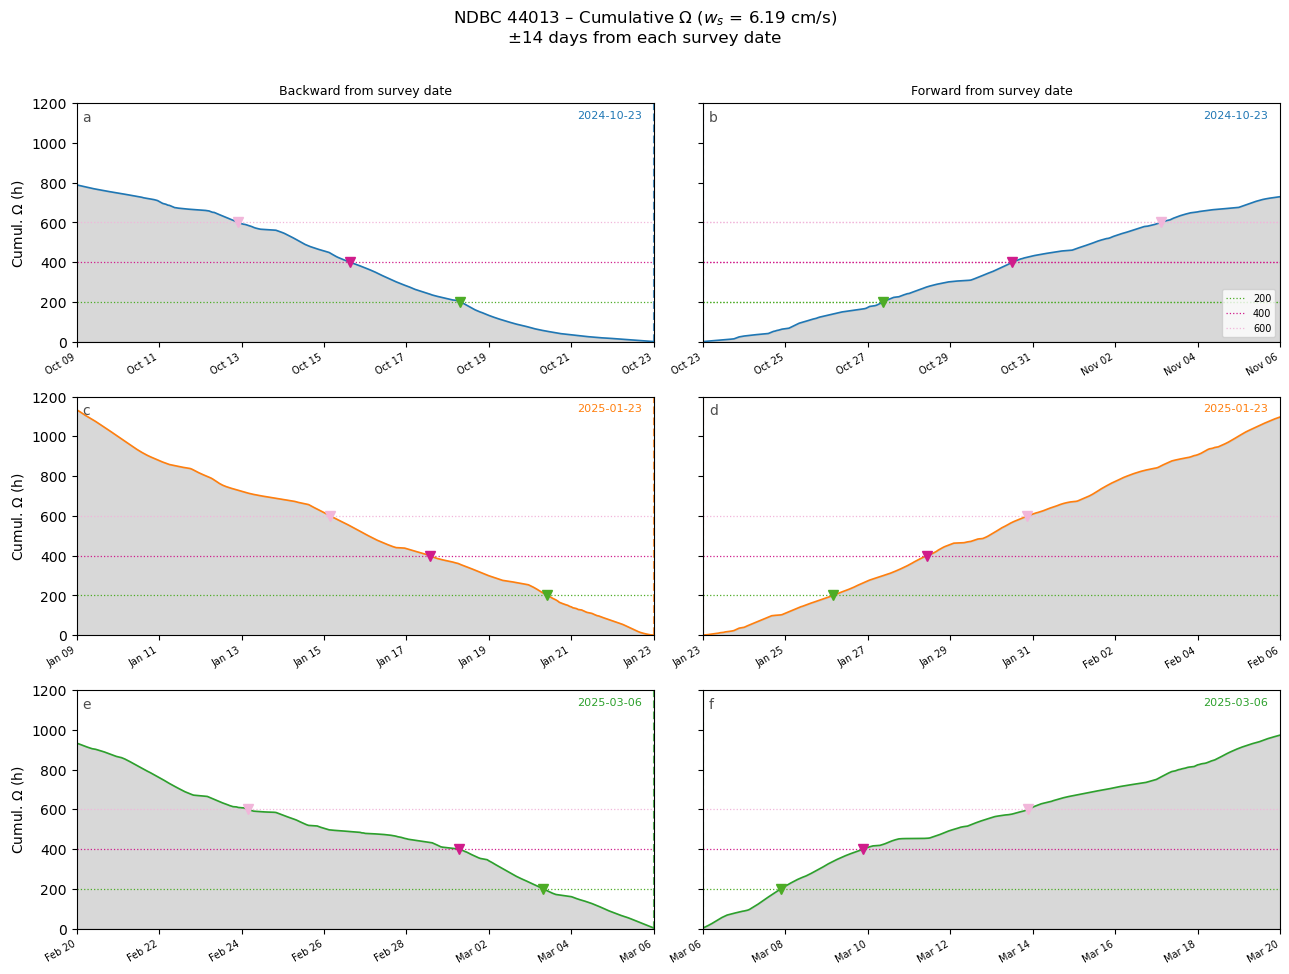

In [6]:
# ── Figure 2 – Cumulative Omega, fixed y-axis with threshold lines ────────────
n_surveys = len(SURVEY_DATES)
fig, axes = plt.subplots(n_surveys, 2, figsize=(13, 3.2 * n_surveys), sharey=True)

panel_letters = [chr(ord('a') + i) for i in range(2 * n_surveys)]
panel_idx = 0

for row, (sd, sc) in enumerate(zip(SURVEY_DATES, SURVEY_COLORS)):
    key = sd.strftime('%Y-%m-%d')

    for col, (direction, title) in enumerate([
            ('bwd', 'Backward from survey date'),
            ('fwd', 'Forward from survey date')]):

        s  = cum[key][direction]['Omega_h']
        ax = axes[row, col]

        ax.fill_between(s.index, s.values, color=SHADE_COLOR, alpha=0.6)
        ax.plot(s.index, s.values, color=sc, lw=1.2)
        ax.axvline(sd, color=sc, lw=1.5, ls='--', alpha=0.8)

        for thresh, tc in zip(THRESHOLDS, THRESH_COLORS):
            ax.axhline(thresh, color=tc, lw=0.9, ls=':', zorder=2)
            above = s.values >= thresh
            diff  = np.diff(above.astype(int))
            sign  = 1 if direction == 'fwd' else -1
            cross = np.where(diff == sign)[0]
            for i in cross:
                frac    = (thresh - s.values[i]) / (s.values[i+1] - s.values[i])
                t_cross = s.index[i] + frac * (s.index[i+1] - s.index[i])
                ax.plot(t_cross, thresh, marker='v', color=tc, ms=7, zorder=5)

        ax.set_xlim(s.index[0], s.index[-1])
        ax.set_ylim(0, YMAX)
        if col == 0:
            ax.set_ylabel(r'Cumul. $\Omega$ (h)')
        if row == 0:
            ax.set_title(title, fontsize=9)
        ax.text(0.01, 0.97, panel_letters[panel_idx],
                transform=ax.transAxes, va='top', ha='left', fontsize=10, color='0.3')
        panel_idx += 1
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
        ax.text(0.98, 0.97, key, transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color=sc)

for thresh, tc in zip(THRESHOLDS, THRESH_COLORS):
    axes[0,1].axhline(thresh, color=tc, lw=0.9, ls=':', label=str(thresh))
axes[0,1].legend(fontsize=7, loc='lower right')

fig.suptitle(fr'NDBC {STATION} – Cumulative $\Omega$ ($w_s$ = {WS*100:.2f} cm/s)'
             f'\n±{XLIM_DAYS} days from each survey date', y=1.01)
plt.tight_layout()
plt.savefig(f'NDBC_{STATION}_cumomega.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Tabulate threshold crossing dates ─────────────────────────────────────────
# Linear interpolation between hourly samples gives sub-hourly crossing time.
# 'Days from survey' is positive = after survey (fwd) or before survey (bwd).

def first_crossing(s, thresh, direction):
    """Interpolated datetime when s first crosses thresh; NaT if never reached.
    fwd: ascending crossing; bwd: descending crossing."""
    above = s.values >= thresh
    diff  = np.diff(above.astype(int))
    sign  = 1 if direction == 'fwd' else -1
    cross = np.where(diff == sign)[0]
    if len(cross) == 0:
        return pd.NaT
    i    = cross[0]
    frac = (thresh - s.values[i]) / (s.values[i+1] - s.values[i])
    return s.index[i] + frac * (s.index[i+1] - s.index[i])

rows = []
for sd in SURVEY_DATES:
    key = sd.strftime('%Y-%m-%d')
    for direction in ['bwd', 'fwd']:
        for var, vname in [('P_kWh', 'P (kWh/m)'), ('Omega_h', 'Omega (h)')]:
            s = cum[key][direction][var]
            for thresh in THRESHOLDS:
                t = first_crossing(s, thresh, direction)
                if pd.isnull(t):
                    days = np.nan
                elif direction == 'fwd':
                    days = (t - sd).total_seconds() / 86400
                else:
                    days = (sd - t).total_seconds() / 86400
                rows.append(dict(
                    Survey=key, Dir=direction, Variable=vname,
                    Threshold=thresh,
                    Crossing=t.strftime('%Y-%m-%d %H:%M') if not pd.isnull(t) else 'n/a',
                    Days_from_survey=round(days, 2) if not np.isnan(days) else np.nan,
                ))

df_cross = pd.DataFrame(rows)

for var in ['P (kWh/m)', 'Omega (h)']:
    print(f'\n── {var} ──')
    sub = df_cross[df_cross['Variable']==var].drop(columns='Variable')
    print(sub.to_string(index=False))


── P (kWh/m) ──
    Survey Dir  Threshold         Crossing  Days_from_survey
2024-10-23 bwd        200 2024-10-19 11:47              3.51
2024-10-23 bwd        400 2024-10-18 17:35              4.27
2024-10-23 bwd        600 2024-10-14 16:24              8.32
2024-10-23 fwd        200 2024-10-25 18:46              2.78
2024-10-23 fwd        400 2024-10-27 01:25              4.06
2024-10-23 fwd        600 2024-11-03 01:56             11.08
2025-01-23 bwd        200 2025-01-20 09:50              2.59
2025-01-23 bwd        400 2025-01-16 05:40              6.76
2025-01-23 bwd        600 2025-01-13 22:44              9.05
2025-01-23 fwd        200 2025-01-30 00:23              7.02
2025-01-23 fwd        400 2025-02-01 16:24              9.68
2025-01-23 fwd        600 2025-02-02 03:23             10.14
2025-03-06 bwd        200 2025-03-01 05:46              4.76
2025-03-06 bwd        400 2025-02-24 07:34              9.68
2025-03-06 bwd        600              n/a               NaN
2025-03